In [18]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from glob import glob
from itertools import cycle
import librosa
import librosa.display
import IPython.display as ipd

In [8]:
sns.set_theme(style="white", palette = None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [21]:
class0 = glob("./data/Class0/*/*.mp3")
class1 = glob("./data/Class1/*/*.mp3")

['./data/Class0']


In [20]:
ipd.Audio(class1[10])

IndexError: list index out of range

In [11]:
#raw_data, sample_rate
y, sr = librosa.load(class1[10])
y

array([7.0943788e-06, 3.4075530e-04, 8.2896836e-04, ..., 1.6508844e-02,
       2.1593455e-02, 1.9145492e-02], dtype=float32)

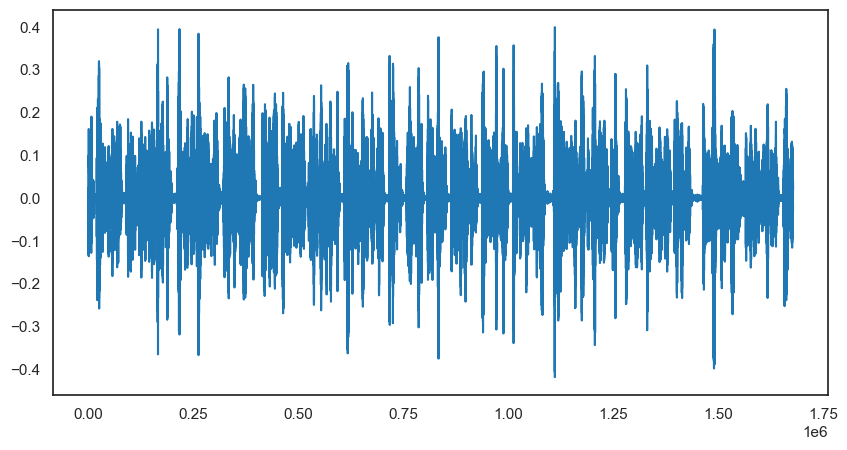

In [12]:
pd.Series(y).plot(figsize = (10,5))
plt.show()

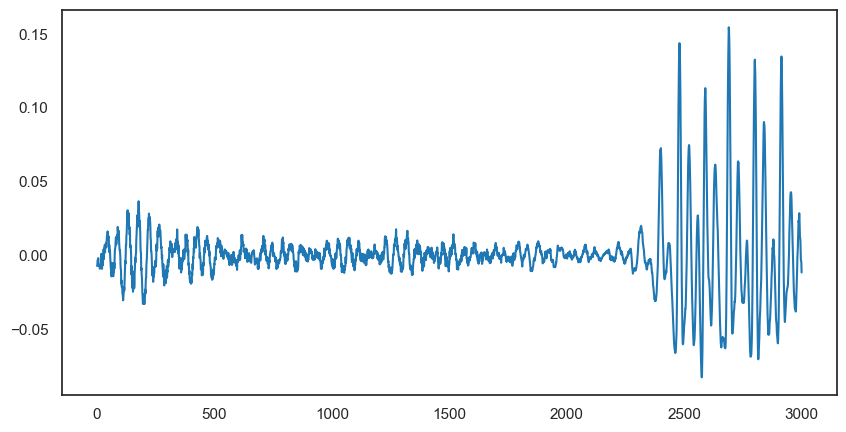

In [13]:
y_trimmed, _ = librosa.effects.trim(y, top_db=20)
pd.Series(y_trimmed[3000:6000]).plot(figsize = (10,5))
plt.show()

In [14]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

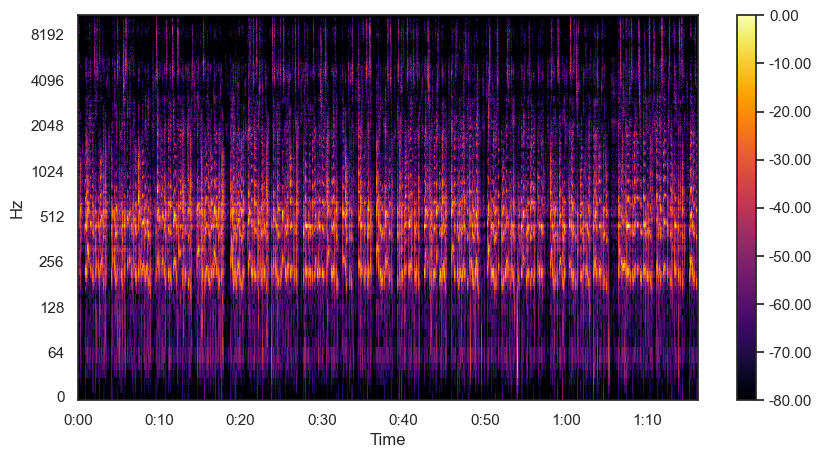

In [15]:
#Spectograms
fig, ax = plt.subplots(figsize = (10,5))
img = librosa.display.specshow(S_db, x_axis='time', y_axis='log', ax=ax, cmap='inferno')
fig.colorbar(img, ax=ax, format = f'%0.2f')
plt.show()

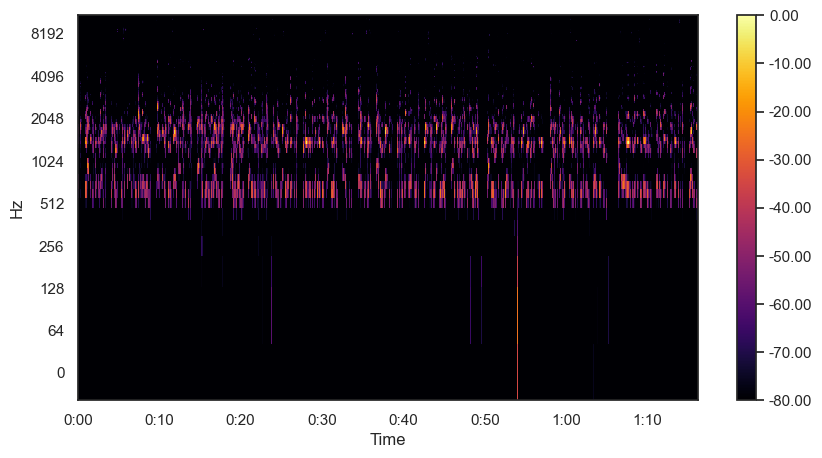

In [16]:
#Melspectograms - present data in the same format that human perceive
S = librosa.feature.melspectrogram(y = y, sr = sr, n_mels = 128,)
S_db_mel = librosa.amplitude_to_db(S, ref=np.max)
fig, ax = plt.subplots(figsize = (10,5))
img = librosa.display.specshow(S_db_mel, x_axis='time', y_axis='log', ax=ax, cmap='inferno')
fig.colorbar(img, ax=ax, format = f'%0.2f')
plt.show()